ARTI406 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

**Dataset: Gym Members Exercise Dataset**
> Source: https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

In this assignment, we will apply practical preprocessing techniques step by step.

In [109]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

## 1. Load Dataset

In [110]:
pd.set_option('display.max_columns', None)

# Load the dataset
# Download from: https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset
df = pd.read_csv('gym_members_exercise_tracking.csv')
df.head(10)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.51,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


## Task 1: Identify Data Quality Issues

examine:
- Data types of each column
- Missing values
- Duplicate rows
- Basic statistics to spot potential issues

In [111]:
# 1.1 Check data types
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Dataset Shape ===')
print(df.shape)

=== Data Types ===
Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

=== Dataset Shape ===
(973, 15)


### 1.2 Convert Incorrect Data Types
1.2.1 Introduce Artificial Incorrect Data Types
Since  my dataset features perfectly formatted columns, I will  introduce artificial data type errors (such as text units and text formatting in numerical columns) for demonstration purposes.

1.2.2 Cleaning and Fixing Data Types
 converting both columns back to their correct numerical formats (float64).

In [ ]:
# 1.Before cleaning (Adding HH:MM format) 
df['Session_Duration (hours)'] = df['Session_Duration (hours)'].astype(str)

df.loc[0, 'Session_Duration (hours)'] = '1:41' 

print("=== Before cleaning (Adding HH:MM format) ===")
print("\nFirst 5 rows:")
print(df['Session_Duration (hours)'].head())

=== Before cleaning (Adding HH:MM format) ===

First 5 rows:
0    1:41
1     1.3
2    1.11
3    0.59
4    0.64
Name: Session_Duration (hours), dtype: object


In [113]:
# 2 . After cleaning (removing HH:MM format)
def fix_duration_format(val):
    val_str = str(val).strip()
    if ':' in val_str:
        hours, minutes = val_str.split(':')
      
        total_hours = float(hours) + (float(minutes) / 60.0)
        
        return round(total_hours, 2)
    
    return round(float(val_str), 2)


df['Session_Duration (hours)'] = df['Session_Duration (hours)'].apply(fix_duration_format)
print("=== After cleaning (removing HH:MM format) ===")
print("\nFirst 5 rows after cleaning:")
print(df['Session_Duration (hours)'].head())

=== After cleaning (removing HH:MM format) ===

First 5 rows after cleaning:
0    1.68
1    1.30
2    1.11
3    0.59
4    0.64
Name: Session_Duration (hours), dtype: float64


In [114]:
# 1. Before cleaning (Adding the unit m )
df['Height (m)'] = df['Height (m)'].astype(str)

# We will take the current value and append the character 'm' to it
df.loc[0, 'Height (m)'] = df.loc[0, 'Height (m)'] + 'm'

print("=== Before cleaning (Adding the unit m ) ===")
print("\nFirst 5 rows of the height column:")
print(df['Height (m)'].head())

=== Before cleaning (Adding the unit m ) ===

First 5 rows of the height column:
0    1.71m
1     1.53
2     1.66
3      1.7
4     1.79
Name: Height (m), dtype: object


In [115]:
#2. After cleaning (removing the unit m )   
df['Height (m)'] = df['Height (m)'].str.replace(r'[m ]', '', regex=True)

df['Height (m)'] = pd.to_numeric(df['Height (m)'])

print("=== After cleaning (removing the unit m ) ===")
print("\nFirst 5 rows after cleaning :")
print(df['Height (m)'].head())

=== After cleaning (removing the unit m ) ===

First 5 rows after cleaning :
0    1.71
1    1.53
2    1.66
3    1.70
4    1.79
Name: Height (m), dtype: float64


In [116]:
# 1.3 Check for missing values
print('=== Missing Values ===')
missing = df.isna().sum()
print(missing[missing >= 0])

=== Missing Values ===
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


In [117]:
# 1.4 Check for duplicate rows
print('=== Duplicate Rows ===')
print(f'Number of duplicates: {df.duplicated().sum()}')

=== Duplicate Rows ===
Number of duplicates: 0


In [118]:
# 1.5 Basic statistics
print('=== Descriptive Statistics ===')
df.describe()

=== Descriptive Statistics ===


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256413,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343021,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


## Task 2: Handle Missing Values

### Strategy Selection
I will introduce artificial missing values to demonstrate handling strategies.
For numerical columns like `Height (m)	` , we will use **median imputation**.

**Why Median?**
- The median is robust to outliers, unlike the mean.
- Health/fitness data (Height) often has skewed distributions.
- Using the median preserves the central tendency without being influenced by extreme values.

In [119]:
df_missing = df.copy()
df_missing.loc[0:30, 'Height (m)'] = np.nan
df_missing.isna().sum()

Age                               0
Gender                            0
Weight (kg)                       0
Height (m)                       31
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   0
Workout_Type                      0
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                               0
dtype: int64

In [121]:
df_missing.head(10)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,NaN,180,157,60,1.68,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,NaN,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,NaN,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,NaN,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,NaN,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,NaN,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,NaN,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,NaN,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,NaN,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,NaN,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


In [122]:
# Fill missing values with median
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['Height (m)'].median()
df_imputed_median['Height (m)'] = df_imputed_median['Height (m)'].fillna(median_value)

df_imputed_median.isna().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [146]:
print("Original shape: ",df.shape)
print("Dataset after introducing missing values:", df_missing.shape)

Original shape:  (973, 15)
Dataset after introducing missing values: (973, 15)


In [123]:
df_imputed_median.head(10)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.68,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.71,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.71,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.71,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.71,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.71,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,1.71,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.71,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.71,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.71,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


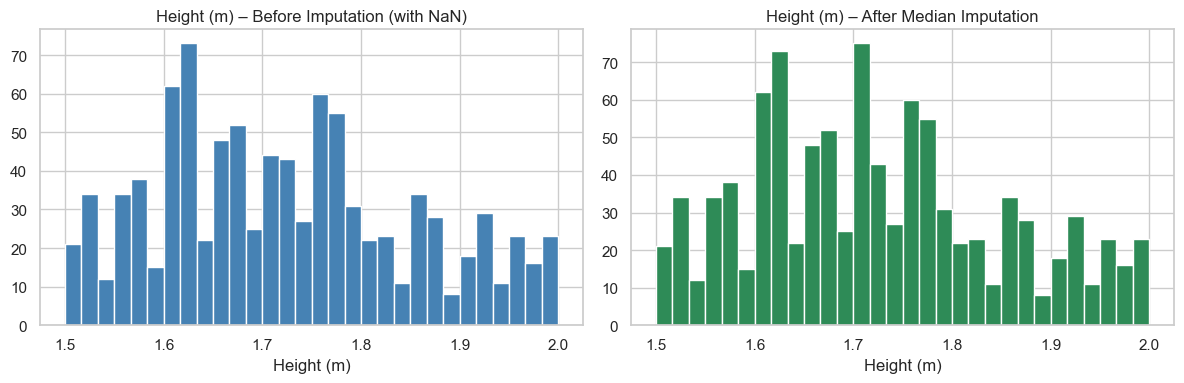

In [124]:
# Visualize distribution before and after imputation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_missing['Height (m)'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Height (m) – Before Imputation (with NaN)')
axes[0].set_xlabel('Height (m)')

axes[1].hist(df_imputed_median['Height (m)'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Height (m) – After Median Imputation')
axes[1].set_xlabel('Height (m)')

plt.tight_layout()
plt.show()

Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## Task 3: Detect and Handle Outliers Using IQR

We use the **Interquartile Range (IQR)** method:
- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR
- Any value outside these bounds is considered an outlier.

We will check `Calories_Burned` , `Session_Duration (hours)` and  ` Max_BPM` .

In [143]:
# Detect outliers using IQR
cols_to_check = ['Calories_Burned', 'Session_Duration (hours)', 'Max_BPM']

for col in cols_to_check:
    Q1 = df_imputed_median[col].quantile(0.25)
    Q3 = df_imputed_median[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = df_imputed_median[(df_imputed_median[col] < lower) | (df_imputed_median[col] > upper)].shape[0]
    print(f'{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, Lower={lower:.2f}, Upper={upper:.2f}, Outliers={n_outliers}')

Calories_Burned: Q1=720.00, Q3=1076.00, IQR=356.00, Lower=186.00, Upper=1610.00, Outliers=10
Session_Duration (hours): Q1=1.04, Q3=1.46, IQR=0.42, Lower=0.41, Upper=2.09, Outliers=0
Max_BPM: Q1=170.00, Q3=190.00, IQR=20.00, Lower=140.00, Upper=220.00, Outliers=0


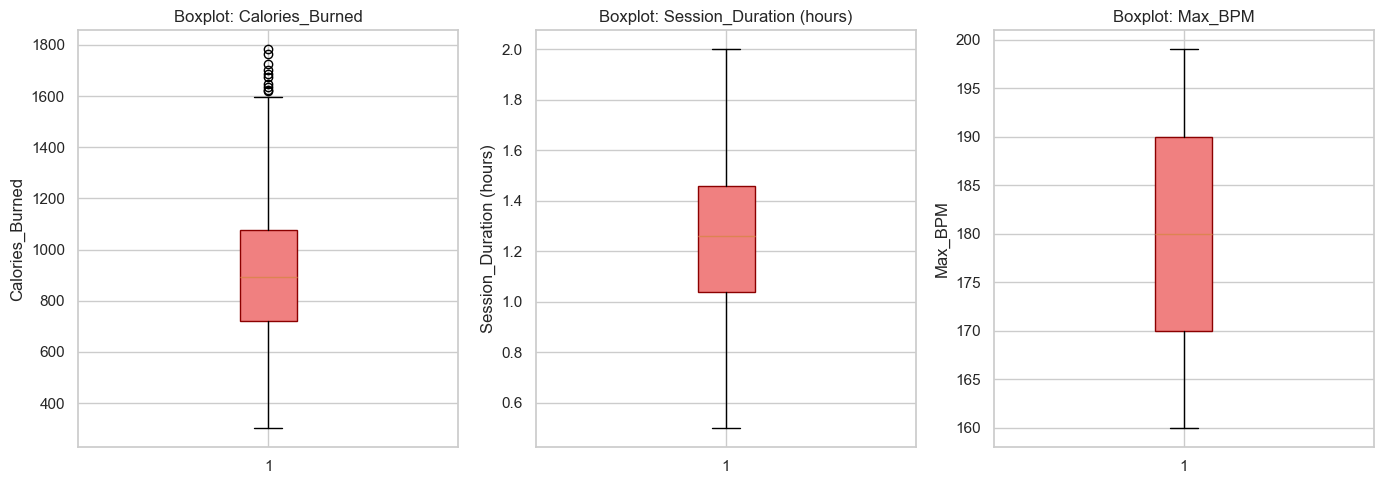

In [126]:
# Boxplot visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, ['Calories_Burned', 'Session_Duration (hours)', 'Max_BPM']):
    ax.boxplot(df_imputed_median[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightcoral', color='darkred'))
    ax.set_title(f'Boxplot: {col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [141]:
# Remove outliers using IQR for Calories_Burned
col = 'Calories_Burned'
Q1 = df_imputed_median[col].quantile(0.25)
Q3 = df_imputed_median[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outliers = df_imputed_median[(df_imputed_median[col] >= lower) & (df_imputed_median[col] <= upper)].copy()

print(f'Shape before removing outliers: {df_imputed_median.shape}')
print(f'Shape after  removing outliers: {df_no_outliers.shape}')
print(f'Rows removed: {df_imputed_median.shape[0] - df_no_outliers.shape[0]}')

outliers = df_imputed_median[(df_imputed_median[col] < lower) | (df_imputed_median[col] > upper)]
outliers.head(15)

Shape before removing outliers: (973, 15)
Shape after  removing outliers: (963, 15)
Rows removed: 10


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
90,25,Male,81.5,1.61,170,159,63,1.93,1688.0,HIIT,10.9,3.5,4,3,31.44
99,24,Female,60.1,1.79,170,165,63,1.97,1625.0,Cardio,15.9,2.7,4,3,18.76
124,26,Male,86.2,1.68,189,157,72,1.97,1701.0,Strength,13.3,3.5,5,3,30.54
475,27,Male,89.3,1.64,192,162,64,1.82,1622.0,HIIT,12.1,3.5,4,3,33.20
511,39,Male,86.2,1.82,191,160,72,1.96,1725.0,Strength,10.2,3.5,5,3,26.02
572,36,Male,88.0,1.71,185,160,73,1.87,1646.0,HIIT,12.0,3.5,5,3,30.09
646,22,Male,88.5,1.62,174,162,69,1.88,1675.0,Strength,10.7,3.5,5,3,33.72
712,19,Male,82.4,1.96,174,169,62,1.90,1766.0,HIIT,10.1,3.5,5,3,21.45
728,47,Male,87.2,1.64,177,165,50,2.00,1634.0,Strength,15.0,3.5,4,3,32.42
910,32,Male,89.8,1.92,199,168,67,1.93,1783.0,Strength,10.6,3.5,4,3,24.36


In [144]:
# or
#  Capping Outliers (Percentile Method)
lower_cap = df['Calories_Burned'].quantile(0.05)
upper_cap = df['Calories_Burned'].quantile(0.95)

df_capped = df.copy()
df_capped['Calories_Burned'] = df_capped['Calories_Burned'].clip(lower_cap, upper_cap)

> **Note:** Outlier removal was demonstrated on `Calories_Burned` as an example. 
> The same procedure can be applied to the remaining numerical variables.

## Task 4: Normalize Numerical Features

We apply two normalization methods:

### Min-Max Normalization
Scales all values to a [0, 1] range.
Formula: `x_scaled = (x - x_min) / (x_max - x_min)`

**When to use:** When the algorithm requires bounded input (e.g., neural networks, KNN).

### Z-score Standardization
Transforms data to have mean=0 and std=1.
Formula: `x_scaled = (x - mean) / std`

**When to use:** When features have different units or when the algorithm assumes normal distribution (e.g., SVM, linear regression).

In [129]:
# Select numerical features
num_cols = ['Weight (kg)', 'Calories_Burned', 'Session_Duration (hours)', 
            'Height (m)', 'Max_BPM', 'Resting_BPM', 'Age',
            'Water_Intake (liters)', 'Workout_Frequency (days/week)', 
            'Fat_Percentage', 'BMI']

# Min-Max Normalization
minmax_scaler = MinMaxScaler()
df_minmax = df_no_outliers[num_cols].copy()
df_minmax[num_cols] = minmax_scaler.fit_transform(df_no_outliers[num_cols])

print('=== Min-Max Normalized (first 5 rows) ===')
print(df_minmax.head())
print()
print('Min:', df_minmax.min().values)
print('Max:', df_minmax.max().values)

=== Min-Max Normalized (first 5 rows) ===
   Weight (kg)  Calories_Burned  Session_Duration (hours)  Height (m)  \
0     0.537264         0.779923                  0.791946        0.42   
1     0.388209         0.447876                  0.536913        0.42   
2     0.312570         0.288803                  0.409396        0.42   
3     0.146830         0.176834                  0.060403        0.42   
4     0.067853         0.195367                  0.093960        0.42   

    Max_BPM  Resting_BPM       Age  Water_Intake (liters)  \
0  0.512821     0.416667  0.926829               0.909091   
1  0.487179     0.666667  0.682927               0.272727   
2  0.179487     0.166667  0.341463               0.363636   
3  0.769231     0.250000  0.170732               0.272727   
4  0.717949     0.750000  0.487805               0.590909   

   Workout_Frequency (days/week)  Fat_Percentage       BMI  
0                       0.666667           0.104  0.476546  
1                       0.6666

In [130]:
# Z-score Standardization
zscore_scaler = StandardScaler()
df_zscore = df_no_outliers[num_cols].copy()
df_zscore[num_cols] = zscore_scaler.fit_transform(df_no_outliers[num_cols])

print('=== Z-score Standardized (first 5 rows) ===')
print(df_zscore.head())
print()
print('Mean:', df_zscore.mean().round(4).values)
print('Std: ', df_zscore.std().round(4).values)

=== Z-score Standardized (first 5 rows) ===
   Weight (kg)  Calories_Burned  Session_Duration (hours)  Height (m)  \
0     0.684236         1.587151                  1.274654   -0.093131   
1     0.054074        -0.054643                  0.149547   -0.093131   
2    -0.265710        -0.841177                 -0.413007   -0.093131   
3    -0.966412        -1.394805                 -1.952627   -0.093131   
4    -1.300304        -1.303170                 -1.804586   -0.093131   

    Max_BPM  Resting_BPM       Age  Water_Intake (liters)  \
0  0.012065    -0.298893  1.414746               1.476830   
1 -0.074638     0.520369  0.593330              -0.868355   
2 -1.115071    -1.118154 -0.556652              -0.533329   
3  0.879092    -0.845067 -1.131643              -0.868355   
4  0.705687     0.793456 -0.063803               0.304237   

   Workout_Frequency (days/week)  Fat_Percentage       BMI  
0                       0.760602       -2.035878  0.798593  
1                       0.76

After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

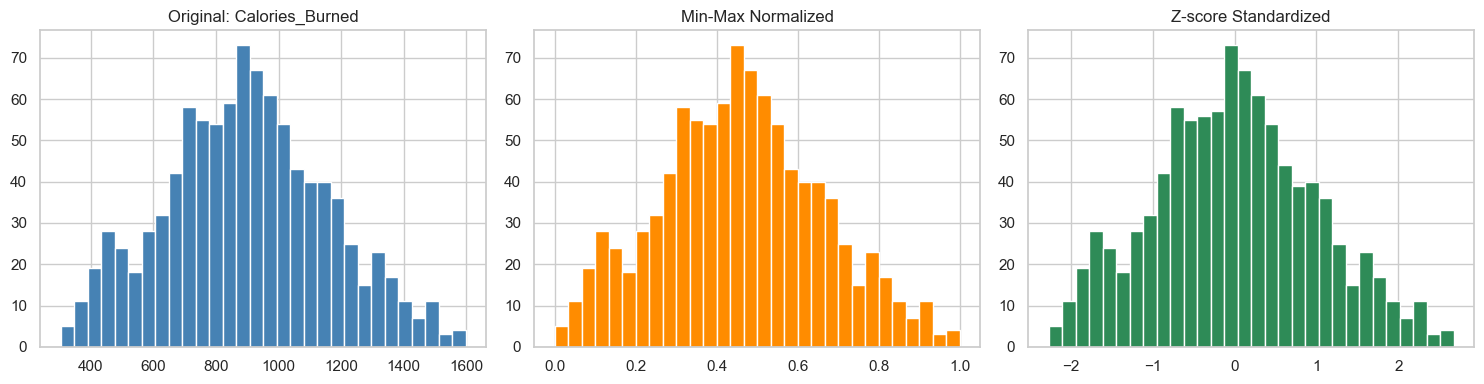

In [134]:
# Compare original vs Min-Max vs Z-score for Calories_Burned
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_no_outliers['Calories_Burned'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Original: Calories_Burned')

axes[1].hist(df_minmax['Calories_Burned'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Min-Max Normalized')

axes[2].hist(df_zscore['Calories_Burned'], bins=30, color='seagreen', edgecolor='white')
axes[2].set_title('Z-score Standardized')

plt.tight_layout()
plt.show()

## Task 5: Apply PCA and Interpret Explained Variance

**Principal Component Analysis (PCA)** reduces the dimensionality of the dataset while retaining the most important variation.

Steps:
1. Check Correlation Before Applying PCA
2. Apply PCA on the Z-score standardized data.
3. Examine how much variance each component explains.
4. Visualize the 2D projection.

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful 
because we can combine correlated features into fewer components.

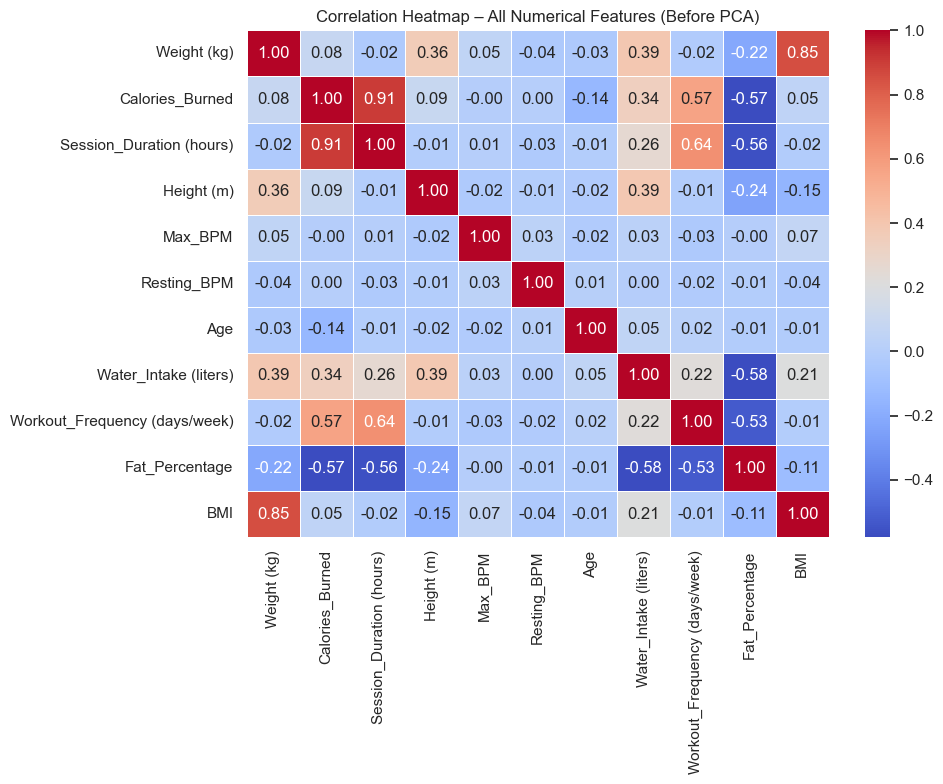

In [135]:
# Check Correlation Before Applying PCA
plt.figure(figsize=(10, 8))
sns.heatmap(df_zscore[num_cols].corr(), 
            annot=True, fmt=".2f", cmap="coolwarm", 
            linewidths=0.5)
plt.title("Correlation Heatmap – All Numerical Features (Before PCA)")
plt.tight_layout()
plt.show()

The heatmap shows the correlation between all 11 numerical features:

- The diagonal values are 1 because each feature is perfectly correlated with itself.
- Some feature pairs show moderate to strong correlations, for example:
  - `Calories_Burned` and `Session_Duration (hours)` tend to be positively correlated, is approximately *0.91*..
  - `BMI` and `Weight (kg)` are expected to show a strong positive correlation ,is approximately *0.85*..
- Features with correlation close to 0 have **weak or no linear relationship**.

When multiple features are correlated, they carry overlapping information.
PCA is useful in this case because it combines these correlated features into 
fewer components, reducing redundancy while retaining most of the variance.

In [136]:
# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(df_zscore[num_cols])

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('=== Explained Variance Ratio per Component ===')
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f'PC{i+1}: {ev:.4f} ({ev*100:.2f}%)  |  Cumulative: {cv*100:.2f}%')

=== Explained Variance Ratio per Component ===
PC1: 0.2943 (29.43%)  |  Cumulative: 29.43%
PC2: 0.1842 (18.42%)  |  Cumulative: 47.85%
PC3: 0.1153 (11.53%)  |  Cumulative: 59.38%
PC4: 0.0943 (9.43%)  |  Cumulative: 68.80%
PC5: 0.0940 (9.40%)  |  Cumulative: 78.20%
PC6: 0.0865 (8.65%)  |  Cumulative: 86.85%
PC7: 0.0514 (5.14%)  |  Cumulative: 91.99%
PC8: 0.0439 (4.39%)  |  Cumulative: 96.38%
PC9: 0.0288 (2.88%)  |  Cumulative: 99.26%
PC10: 0.0064 (0.64%)  |  Cumulative: 99.91%
PC11: 0.0009 (0.09%)  |  Cumulative: 100.00%


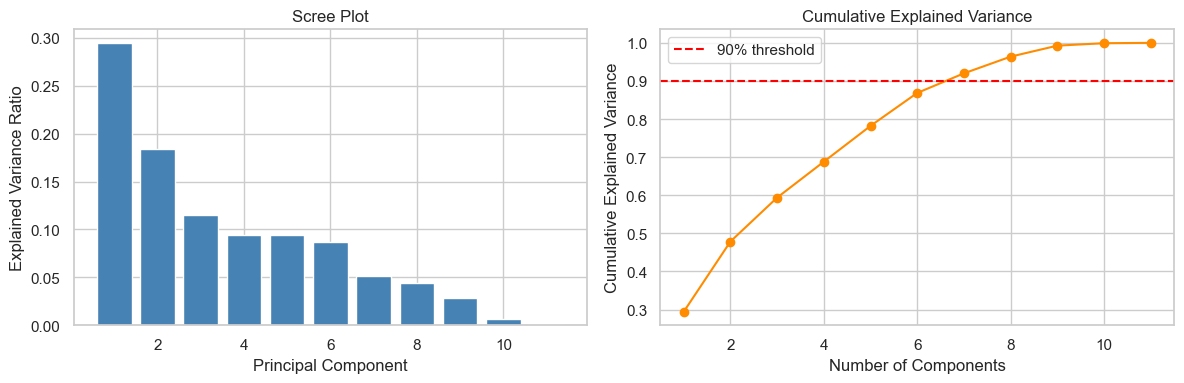

In [137]:
# Scree Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained_variance)+1), explained_variance, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', color='darkorange')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

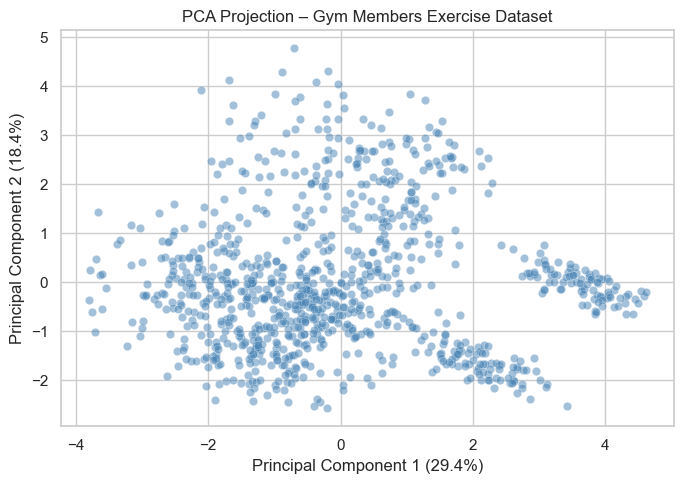

In [ ]:
# visualize the relationship between features using a scatter plot. 
# 2D PCA Projection
pca2 = PCA(n_components=2)
pc2 = pca2.fit_transform(df_zscore[num_cols])

plt.figure(figsize=(7, 5))
plt.scatter(pc2[:, 0], pc2[:, 1], alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.3)
plt.title('PCA Projection – Gym Members Exercise Dataset')
plt.xlabel(f'Principal Component 1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.show()

### PCA Interpretation

After applying PCA on the 11 standardized numerical features:

- **PC1** explains approximately **29.43%** of the total variance, capturing the dominant 
  direction of variation in the data — likely related to overall workout intensity 
  (calories burned, BPM, session duration).

- **PC2** explains approximately **18.42%**, likely reflecting body composition 
  patterns (age, weight, height).

- Together, **PC1 and PC2 explain 47.85%** of the total variance, meaning we can 
  represent the dataset in just 2 dimensions while retaining roughly half the information.

- The **Scree Plot** shows the 'elbow' point after PC3, confirming that the first 
  7 components are sufficient to explain over 90% of the variance (91.99%).

- The **2D projection** visualizes all gym members in a reduced space. The spread 
  of points suggests no clear clusters in workout behavior or fitness level.

- Since only 47.85% of variance is retained with 2 components, PCA is 
  **moderately effective** for this dataset — more components are needed to 
  fully represent the data without significant information loss.

The first few principal components capture most of the dataset variability, 
indicating that dimensionality can be reduced with limited information loss.

# Conclusion

This assignment demonstrated the complete data preprocessing workflow 
using the Gym Members Exercise Dataset.

The dataset was assessed for data quality issues, including data type 
inconsistencies, missing values, duplicate records, and outliers. 
Artificial examples were introduced where necessary to demonstrate 
preprocessing techniques.

Missing values were handled using median imputation, outliers were 
detected using the IQR method, numerical features were normalized 
using both Min-Max and Z-score scaling, and PCA was applied to reduce 
dimensionality and analyze feature relationships.

These preprocessing steps improve data quality and prepare the dataset 
for future machine learning tasks.